# 03 — Player EDA
Top batsmen, bowlers, SR vs Avg, phase analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.facecolor'] = '#1a1a2e'
plt.rcParams['figure.facecolor'] = '#16213e'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.titlecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#444'
ACCENT = '#f5a623'
PALETTE = ['#f5a623','#e74c3c','#3498db','#2ecc71','#9b59b6','#1abc9c','#e67e22','#e91e63','#00bcd4','#ff5722']

deliveries = pd.read_csv('../data/processed/deliveries_clean.csv')
matches = pd.read_csv('../data/processed/matches_clean.csv')
print(f'Deliveries: {len(deliveries)} | Batters: {deliveries["batter"].nunique()} | Bowlers: {deliveries["bowler"].nunique()}')

Deliveries: 260920 | Batters: 673 | Bowlers: 530


## 1. Top 15 Run Scorers (All Time)

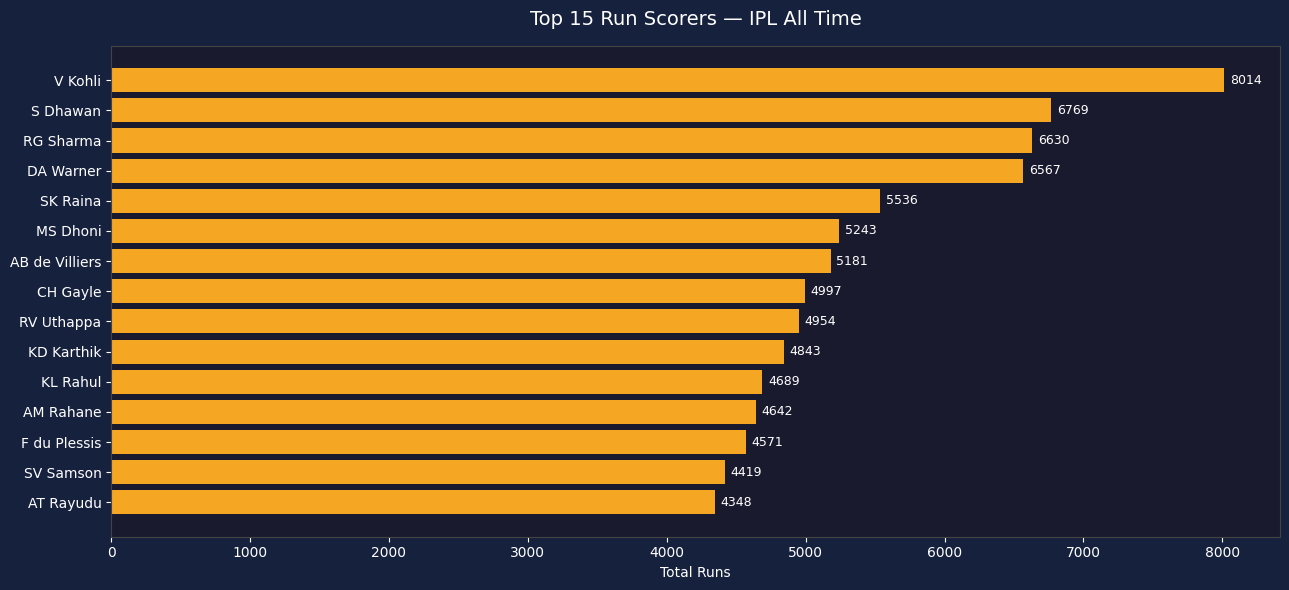

        batter  runs
       V Kohli  8014
      S Dhawan  6769
     RG Sharma  6630
     DA Warner  6567
      SK Raina  5536
      MS Dhoni  5243
AB de Villiers  5181
      CH Gayle  4997
    RV Uthappa  4954
    KD Karthik  4843
      KL Rahul  4689
     AM Rahane  4642
  F du Plessis  4571
     SV Samson  4419
     AT Rayudu  4348


In [2]:
runs = deliveries.groupby('batter')['batsman_runs'].sum().reset_index()
runs.columns = ['batter', 'runs']
runs = runs.sort_values('runs', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(runs['batter'], runs['runs'], color=ACCENT, edgecolor='none')
ax.bar_label(bars, padding=4, color='white', fontsize=9)
ax.set_title('Top 15 Run Scorers — IPL All Time', fontsize=14, pad=15)
ax.set_xlabel('Total Runs')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../assets/07_top_run_scorers.png', dpi=150, bbox_inches='tight')
plt.show()
print(runs.to_string(index=False))

## 2. Strike Rate vs Average — Bubble Chart (Top 40 Batsmen)

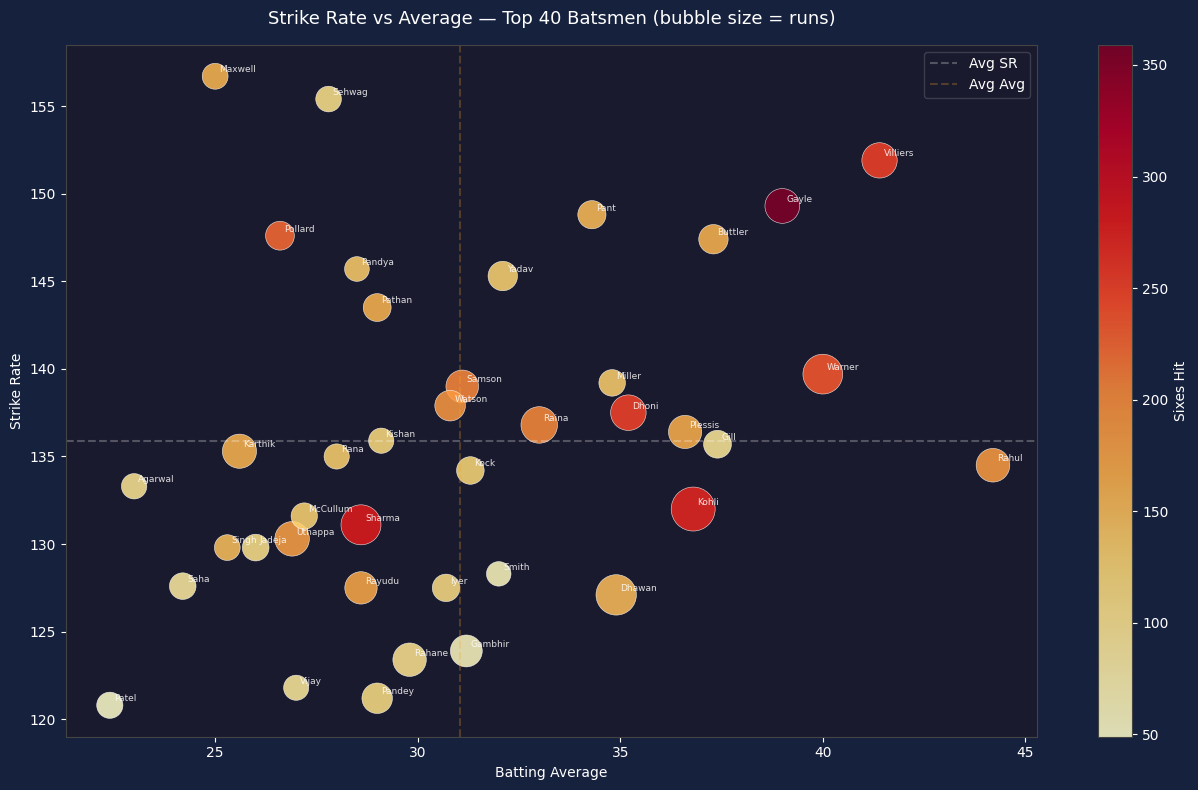

In [3]:
# Only count legal balls for SR (no wides)
legal = deliveries[deliveries['extras_type'] != 'wides']
balls = legal.groupby('batter').size().reset_index(name='balls_faced')

batter_stats = deliveries.groupby('batter').agg(
    runs=('batsman_runs', 'sum'),
    innings=('match_id', 'nunique'),
    fours=('is_four', 'sum'),
    sixes=('is_six', 'sum'),
    dismissals=('is_wicket', 'sum')
).reset_index()

batter_stats = batter_stats.merge(balls, on='batter')
batter_stats['strike_rate'] = (batter_stats['runs'] / batter_stats['balls_faced'] * 100).round(1)
batter_stats['average'] = (batter_stats['runs'] / batter_stats['dismissals'].replace(0, np.nan)).round(1)

# Filter: min 500 runs
top_batters = batter_stats[batter_stats['runs'] >= 500].dropna(subset=['average']).sort_values('runs', ascending=False).head(40)

fig, ax = plt.subplots(figsize=(13, 8))
scatter = ax.scatter(
    top_batters['average'],
    top_batters['strike_rate'],
    s=top_batters['runs'] / 8,
    c=top_batters['sixes'],
    cmap='YlOrRd',
    alpha=0.85,
    edgecolors='white',
    linewidth=0.4
)
plt.colorbar(scatter, ax=ax, label='Sixes Hit')

for _, row in top_batters.iterrows():
    ax.annotate(row['batter'].split()[-1], (row['average'], row['strike_rate']),
                fontsize=6.5, color='white', alpha=0.85,
                xytext=(3, 3), textcoords='offset points')

ax.axhline(top_batters['strike_rate'].mean(), color='white', linestyle='--', alpha=0.25, label='Avg SR')
ax.axvline(top_batters['average'].mean(), color=ACCENT, linestyle='--', alpha=0.25, label='Avg Avg')
ax.set_xlabel('Batting Average')
ax.set_ylabel('Strike Rate')
ax.set_title('Strike Rate vs Average — Top 40 Batsmen (bubble size = runs)', fontsize=13, pad=15)
ax.legend(framealpha=0.2)
plt.tight_layout()
plt.savefig('../assets/08_sr_vs_avg.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Top 15 Wicket Takers

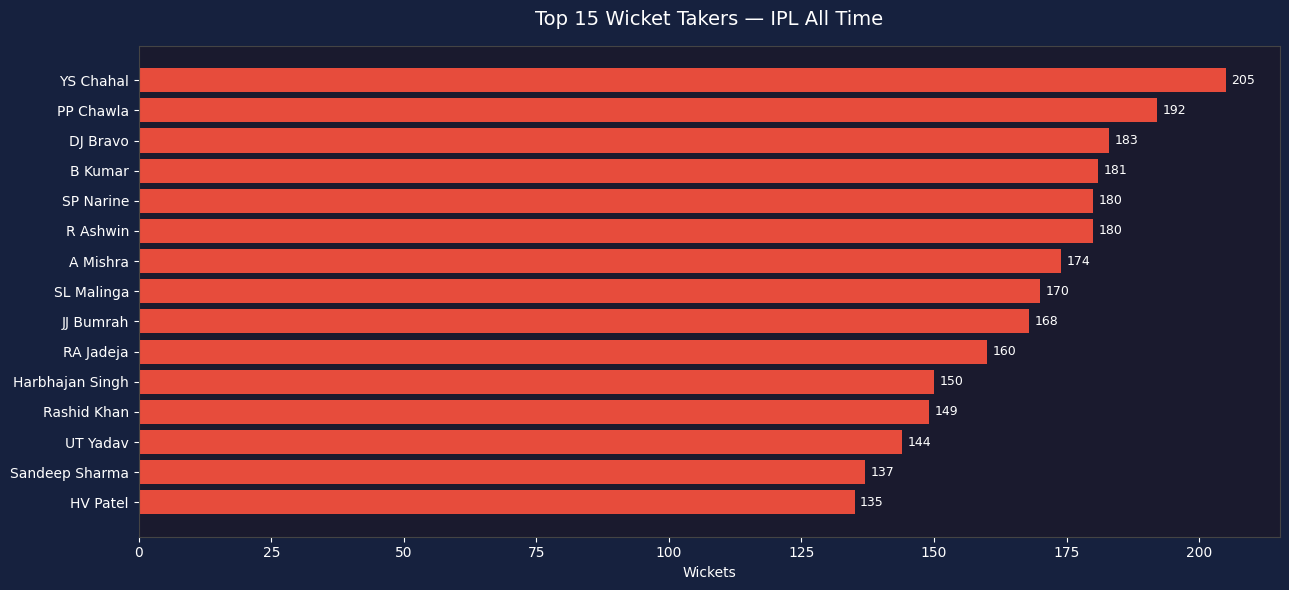

In [4]:
# Exclude run-outs (not credited to bowler)
bowler_wickets = deliveries[
    (deliveries['is_wicket'] == 1) &
    (~deliveries['dismissal_kind'].isin(['run out', 'retired hurt', 'obstructing the field']))
].groupby('bowler').size().reset_index(name='wickets')

bowler_wickets = bowler_wickets.sort_values('wickets', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(bowler_wickets['bowler'], bowler_wickets['wickets'], color='#e74c3c', edgecolor='none')
ax.bar_label(bars, padding=4, color='white', fontsize=9)
ax.set_title('Top 15 Wicket Takers — IPL All Time', fontsize=14, pad=15)
ax.set_xlabel('Wickets')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../assets/09_top_wicket_takers.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Economy Rate vs Wickets — Bowler Scatter (Top 40)

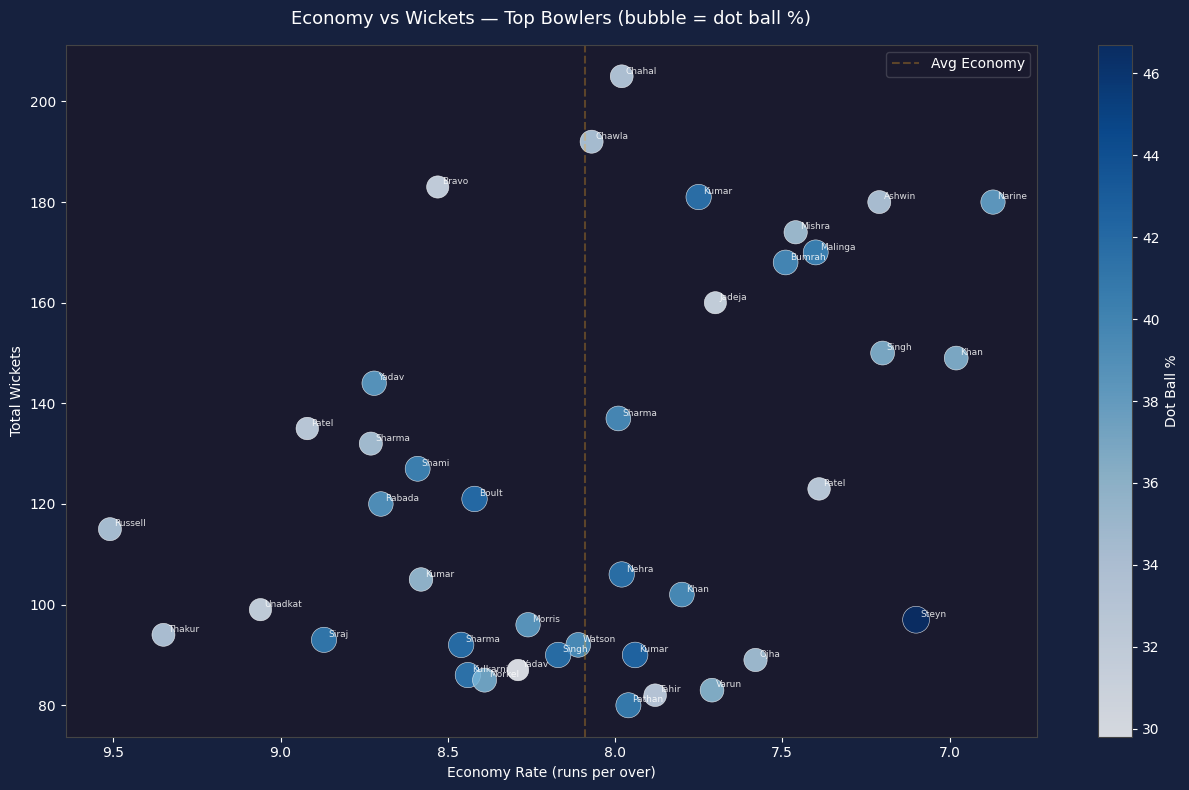

In [5]:
legal_bowler = deliveries[~deliveries['extras_type'].isin(['wides', 'noballs'])]
bowler_balls = legal_bowler.groupby('bowler').size().reset_index(name='balls')
bowler_runs = deliveries.groupby('bowler')['total_runs'].sum().reset_index(name='runs_conceded')
bowler_wkts = deliveries[
    (deliveries['is_wicket'] == 1) &
    (~deliveries['dismissal_kind'].isin(['run out', 'retired hurt', 'obstructing the field']))
].groupby('bowler').size().reset_index(name='wickets')
bowler_dots = deliveries[deliveries['is_dot'] == True].groupby('bowler').size().reset_index(name='dots')

bowler_stats = bowler_balls.merge(bowler_runs, on='bowler').merge(bowler_wkts, on='bowler').merge(bowler_dots, on='bowler')
bowler_stats['overs'] = bowler_stats['balls'] / 6
bowler_stats['economy'] = (bowler_stats['runs_conceded'] / bowler_stats['overs']).round(2)
bowler_stats['dot_pct'] = (bowler_stats['dots'] / bowler_stats['balls'] * 100).round(1)

top_bowlers = bowler_stats[bowler_stats['wickets'] >= 30].sort_values('wickets', ascending=False).head(40)

fig, ax = plt.subplots(figsize=(13, 8))
scatter = ax.scatter(
    top_bowlers['economy'],
    top_bowlers['wickets'],
    s=top_bowlers['dot_pct'] * 8,
    c=top_bowlers['dot_pct'],
    cmap='Blues',
    alpha=0.85,
    edgecolors='white',
    linewidth=0.4
)
plt.colorbar(scatter, ax=ax, label='Dot Ball %')

for _, row in top_bowlers.iterrows():
    ax.annotate(row['bowler'].split()[-1], (row['economy'], row['wickets']),
                fontsize=6.5, color='white', alpha=0.85,
                xytext=(3, 2), textcoords='offset points')

ax.axvline(top_bowlers['economy'].mean(), color=ACCENT, linestyle='--', alpha=0.3, label='Avg Economy')
ax.set_xlabel('Economy Rate (runs per over)')
ax.set_ylabel('Total Wickets')
ax.set_title('Economy vs Wickets — Top Bowlers (bubble = dot ball %)', fontsize=13, pad=15)
ax.legend(framealpha=0.2)
ax.invert_xaxis()  # Lower economy = better = right side
plt.tight_layout()
plt.savefig('../assets/10_economy_vs_wickets.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Runs by Phase — Which Phase Produces Most Runs?

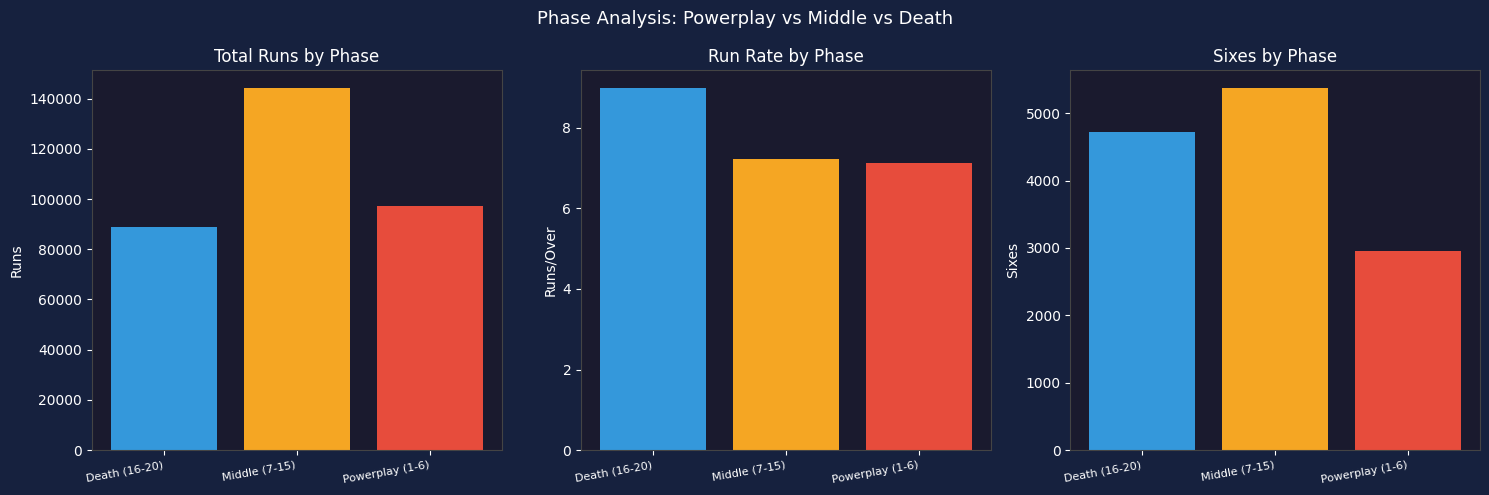

             phase  total_runs  boundaries  sixes   dots   balls  run_rate
0    Death (16-20)       88907       11506   4725  16099   59463      8.97
1    Middle (7-15)      144028       15903   5366  37350  119552      7.23
2  Powerplay (1-6)       97129       15492   2960  36989   81905      7.12


In [6]:
phase_runs = deliveries.groupby('phase').agg(
    total_runs=('batsman_runs', 'sum'),
    boundaries=('is_boundary', 'sum'),
    sixes=('is_six', 'sum'),
    dots=('is_dot', 'sum'),
    balls=('ball', 'count')
).reset_index()
phase_runs['run_rate'] = (phase_runs['total_runs'] / phase_runs['balls'] * 6).round(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
phases = phase_runs['phase'].tolist()
colors = ['#3498db', ACCENT, '#e74c3c']

axes[0].bar(phases, phase_runs['total_runs'], color=colors, edgecolor='none')
axes[0].set_title('Total Runs by Phase')
axes[0].set_ylabel('Runs')

axes[1].bar(phases, phase_runs['run_rate'], color=colors, edgecolor='none')
axes[1].set_title('Run Rate by Phase')
axes[1].set_ylabel('Runs/Over')

axes[2].bar(phases, phase_runs['sixes'], color=colors, edgecolor='none')
axes[2].set_title('Sixes by Phase')
axes[2].set_ylabel('Sixes')

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=10, ha='right', fontsize=8)

plt.suptitle('Phase Analysis: Powerplay vs Middle vs Death', fontsize=13)
plt.tight_layout()
plt.savefig('../assets/11_phase_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(phase_runs)

## 6. Player of the Match — Most Awards

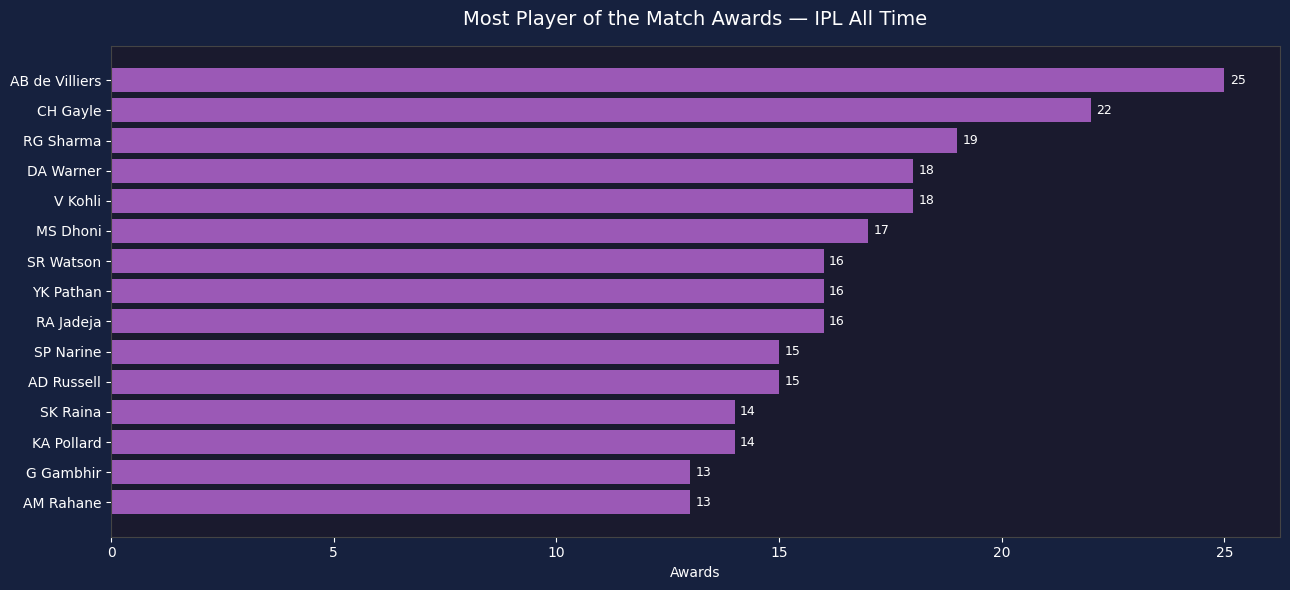

In [7]:
potm = matches[matches['player_of_match'] != 'N/A']['player_of_match'].value_counts().head(15).reset_index()
potm.columns = ['player', 'awards']

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(potm['player'], potm['awards'], color='#9b59b6', edgecolor='none')
ax.bar_label(bars, padding=4, color='white', fontsize=9)
ax.set_title('Most Player of the Match Awards — IPL All Time', fontsize=14, pad=15)
ax.set_xlabel('Awards')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../assets/12_potm.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Export Player Stats for Power BI

In [8]:
# Batter summary
batter_export = batter_stats[batter_stats['runs'] >= 100].copy()
batter_export.to_csv('../data/processed/batter_stats.csv', index=False)

# Bowler summary
bowler_stats.to_csv('../data/processed/bowler_stats.csv', index=False)

print('Saved batter_stats.csv and bowler_stats.csv')
print(f'Batters: {len(batter_export)} | Bowlers: {len(bowler_stats)}')

Saved batter_stats.csv and bowler_stats.csv
Batters: 304 | Bowlers: 451
